In [291]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline 
words = open("names.txt","r").read().splitlines() # Open the file and read the file and seperate lines into a list (words)
char = sorted(list(set("".join(words)))) # Make an ordered list of all the characters in the file
stoi = {s:i+1 for i,s in enumerate(char)} # Character to index dict
stoi["."] = 0
itos = {i:s for s,i in stoi.items()} # Index to character dict
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [292]:
def build_dataset(words):
    X,Y = [],[] # Input , Expected Output lists
    block_size = 3 
    num = 0 
    for w in words:
        context = [0]*block_size
        w += "."
        for chr in w:
            ix = stoi[chr]
            X.append(context)
            Y.append(ix) 
            num += 1 # count of total number of characters we assess 
            context = context[1:] + [ix] # Updating the context - window traversion 

    X = torch.tensor(X) # convert to tensors 
    Y = torch.tensor(Y)
    return X,Y
import random
random.seed(43)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xtest,Ytest = build_dataset(words[n2:])

In [293]:
lre = torch.linspace(-3,0,1000) # learning rate exps
lrs = 10**lre


In [302]:
C = torch.randn((27,10),requires_grad = True)  # the look up table that is the same for the three input char 
W1 = torch.randn((30,500),requires_grad = True) # first layer  - 30 inputs for 200 neurons 
b1 = torch.randn(500,requires_grad = True) # first layer bias 
W2 = torch.randn((500,27),requires_grad = True) # second layer - 200 inputs for 27 neurons 
b2 = torch.randn(27,requires_grad = True) # second layer bias
parameters = [C,W1,b1,W2,b2]


In [303]:

stepi = []
lossi = []
n = 0


In [304]:

for i in range(n, n + 50000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]  # the look up table 32,3,2
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # convert the look up table in such a way that we convert the three inputs 2 outputs as a single 6 input
    logits = h @ W2 + b2
    # counts = logits.exp()
    # probs = counts/counts.sum(1,keepdim = 1)
    # loss = -probs[torch.arange(Y.shape[0]),Y].log().mean()
    loss = F.cross_entropy(logits, Ytr[ix])  # the above three lines in one function
    for p in parameters:
        p.grad = None
    
    loss.backward()
    if i < n + 40000:
        lo = 0.1
    else:
        lo = 0.01
    for p in parameters:
        p.data += -lo * p.grad
    stepi.append(i)
    lossi.append(loss.log10().item())


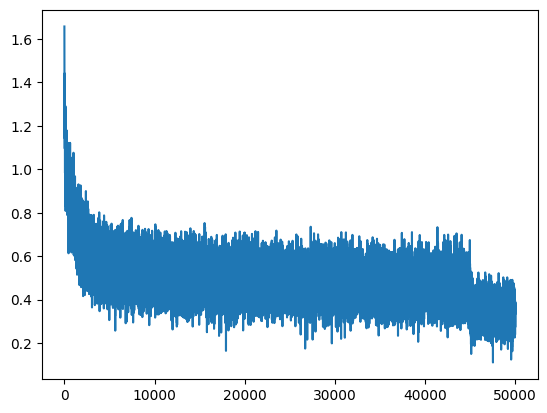

In [297]:
plt.plot(stepi,lossi)

In [306]:

emb = C[Xtr] # the look up table 32,3,2 
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # convert the look up table in such a way that we convert the three inputs 2 outputs as a single 6 input 
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
print(loss.item())

2.221456527709961


In [307]:

emb = C[Xdev] # the look up table 32,3,2 
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # convert the look up table in such a way that we convert the three inputs 2 outputs as a single 6 input 
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ydev)
print(loss.item())


2.315234661102295


In [308]:
emb = C[Xtest] # the look up table 32,3,2 
h = torch.tanh(emb.view(-1,30) @ W1 + b1) # convert the look up table in such a way that we convert the three inputs 2 outputs as a single 6 input 
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytest)
print(loss.item())

2.298407554626465


In [310]:
g = torch.Generator().manual_seed(2147483647 + 20)

for _ in range(20):
    
    out = []
    context = [0] * 3 
    while True:
      emb = C[torch.tensor([context])] 
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))


rasex.
jayson.
licrue.
avasis.
merlyn.
khoire.
aldon.
cylse.
jenne.
malorie.
hairam.
waniosi.
aari.
fadion.
ale.
ann.
ona.
khan.
auwb.
kamalaien.
